# Aliya Harta Ary Utama - 18223081 - Tugas Analitik Data: Multi-class Classification dengan Naive Bayes dan kNN

Notebook ini disiapkan untuk membantu mahasiswa mengerjakan tugas klasifikasi multiclass menggunakan **Naive Bayes** dan **k-Nearest Neighbors (kNN)** menggunakan dataset yang disediakan.

## Tujuan pembelajaran
1. Mengimplementasikan pipeline klasifikasi multiclass.
2. Membandingkan performa **Gaussian Naive Bayes** dan **kNN**.
3. Melakukan **hyperparameter tuning** pada kNN.
4. Menafsirkan hasil melalui metrik evaluasi dan visualisasi aktual vs prediksi.
5. Menyusun kesimpulan berbasis bukti berupa luaran model, visualisasi, dan kinerja model.

> **Catatan pengumpulan**  
> Lengkapi seluruh bagian yang bertanda **TUGAS MAHASISWA**. Sertakan interpretasi singkat setelah setiap output penting.


In [50]:
# =========================
# 1. Import library
# =========================
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [51]:
# =========================
# 2. Load dataset
# =========================
def find_dataset(filename="digital_service_customer_multiclass.csv"):
    candidates = [
        Path.cwd() / filename,
        Path.cwd() / "data" / filename,
        Path("/mnt/data") / filename
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Dataset {filename} tidak ditemukan. Letakkan file pada folder notebook, folder data/, atau /mnt/data/."
    )

data_path = find_dataset()
df = pd.read_csv(data_path)
print("Dataset loaded from:", data_path)
print("Shape:", df.shape)
df.head()


Dataset loaded from: /Users/aliyaharta/Documents/datanal/digital_service_customer_multiclass.csv
Shape: (1000, 18)


,customer_id,age,monthly_usage_hours,avg_session_duration,num_logins_per_week,feature_adoption_score,support_tickets,monthly_spending,payment_consistency_score,tenure_months,engagement_score,last_campaign_response,device_diversity,referral_count,churn_risk_score,preferred_plan,region,segment_class
0,C0522,32.2,46.2,18.0,12.9,89.8,4,459.03,76.5,20.5,62.1,Opened,3,1,28.5,Family,West,Premium
1,C0738,36.3,37.3,13.5,7.6,48.2,3,560.54,96.4,23.7,71.2,No Response,2,2,39.4,Business,Central,Premium
2,C0741,32.2,42.6,11.3,6.4,71.3,1,375.86,78.3,27.4,70.3,Converted,1,1,53.1,Standard,East,Premium
3,C0661,33.4,37.9,17.9,5.0,47.4,1,490.26,67.0,34.9,60.3,Clicked,3,2,43.0,Pro,Central,Premium
4,C0412,34.4,33.9,15.3,7.3,32.7,2,233.42,86.2,9.7,53.6,Clicked,2,0,62.8,Pro,Central,Growth


## TUGAS MAHASISWA 1
Jelaskan secara singkat konteks masalah klasifikasi pada dataset ini dan arti dari target `segment_class`.


Dataset yang diberikan adalah digital_service_customer_multiclass.csv, dimana jika dilihat dari atribut yang dimiliki, dataset ini menjelaskan tentang **segmentasi pelanggan** pada sebuah layanan digital. Tujuannya adalah mengelompokkan pelanggan ke dalam kategori tertentu berdasarkan perilaku mereka (seperti jam penggunaan, pengeluaran bulanan, durasi sesi, dan respons kampanye dll). Dataset ini terdiri dari 1000 row entri data dengan 18 variabel kolom yang membantu menentukan segmentasi pelanggan.  

Variabel *segment_class* ini mewakili/menjelasan tingkatan dari pelanggan yang didasarkan pada data dari variabel lainnya. Segmentasi ini dibagi menjadi beberapa yaitu Enterprise (257 row), Premium (253 row), Growth (245 row), dan Basic (245 row). Tujuan dari segmentasi ini adalah harapannya agar perusahaan dapat melakukan personalisasi strategi pemasaran, meningkatkan retensi, dan mengoptimalkan alokasi sumber daya dukungan pelanggan.  

Klasifikasi ini termasuk multiclass karena ada lebih dari 2 kategori yang perlu diprediksi. Jika terlihat dari persebaran data pada setiap kelas, sekilas bahwa data terdistribusi seimbang. Namun, hal ini akan dibuktikan pada EDA selanjutnya.

In [52]:
# =========================
# 3. Eksplorasi awal
# =========================
print(df.info())
print("\nJumlah missing value per kolom:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDistribusi kelas target:")
display(df["segment_class"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                1000 non-null   object 
 1   age                        1000 non-null   float64
 2   monthly_usage_hours        1000 non-null   float64
 3   avg_session_duration       1000 non-null   float64
 4   num_logins_per_week        1000 non-null   float64
 5   feature_adoption_score     980 non-null    float64
 6   support_tickets            1000 non-null   int64  
 7   monthly_spending           1000 non-null   float64
 8   payment_consistency_score  985 non-null    float64
 9   tenure_months              1000 non-null   float64
 10  engagement_score           1000 non-null   float64
 11  last_campaign_response     985 non-null    object 
 12  device_diversity           1000 non-null   int64  
 13  referral_count             1000 non-null   int64 

feature_adoption_score       20
payment_consistency_score    15
last_campaign_response       15
preferred_plan               10
customer_id                   0
engagement_score              0
region                        0
churn_risk_score              0
referral_count                0
device_diversity              0
tenure_months                 0
age                           0
monthly_spending              0
support_tickets               0
num_logins_per_week           0
avg_session_duration          0
monthly_usage_hours           0
segment_class                 0
dtype: int64


Distribusi kelas target:


segment_class
Enterprise    257
Premium       253
Growth        245
Basic         245
Name: count, dtype: int64

In [53]:
# Statistik deskriptif fitur numerik
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
age,1000.0,32.087000,8.324511,18.0,26.10,32.050,37.925,58.90
monthly_usage_hours,1000.0,37.460600,15.413277,3.0,26.10,37.600,48.600,87.50
avg_session_duration,1000.0,13.828800,6.041529,3.0,9.20,14.000,18.000,29.60
num_logins_per_week,1000.0,7.277000,3.406005,1.0,4.80,7.100,9.700,19.40
feature_adoption_score,980.0,58.962857,20.360967,5.0,45.00,59.950,73.625,100.00
support_tickets,1000.0,2.031000,1.431114,0.0,1.00,2.000,3.000,7.00
monthly_spending,1000.0,398.948820,215.628134,40.0,235.37,386.825,558.640,940.91
payment_consistency_score,985.0,74.505990,15.988527,30.0,63.60,75.400,86.100,100.00
tenure_months,1000.0,22.563500,12.244239,1.0,13.10,22.200,31.125,57.50
engagement_score,1000.0,60.445700,20.299134,10.0,45.70,61.250,75.750,99.00


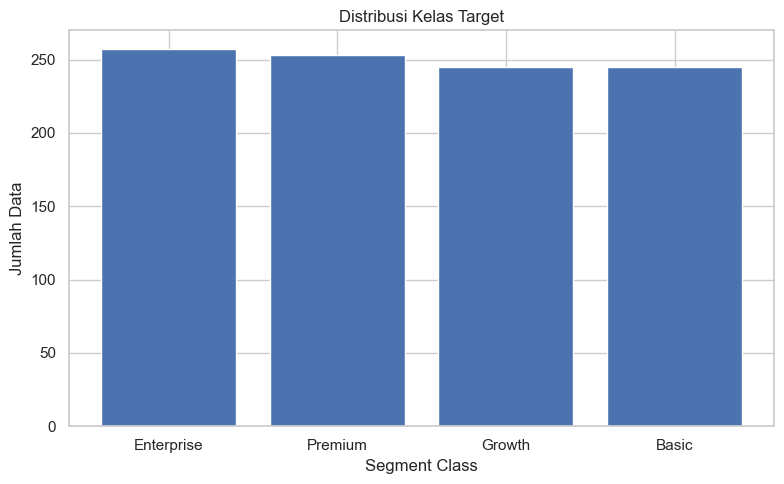

In [54]:
# Visualisasi distribusi kelas target
class_counts = df["segment_class"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Distribusi Kelas Target")
plt.xlabel("Segment Class")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()


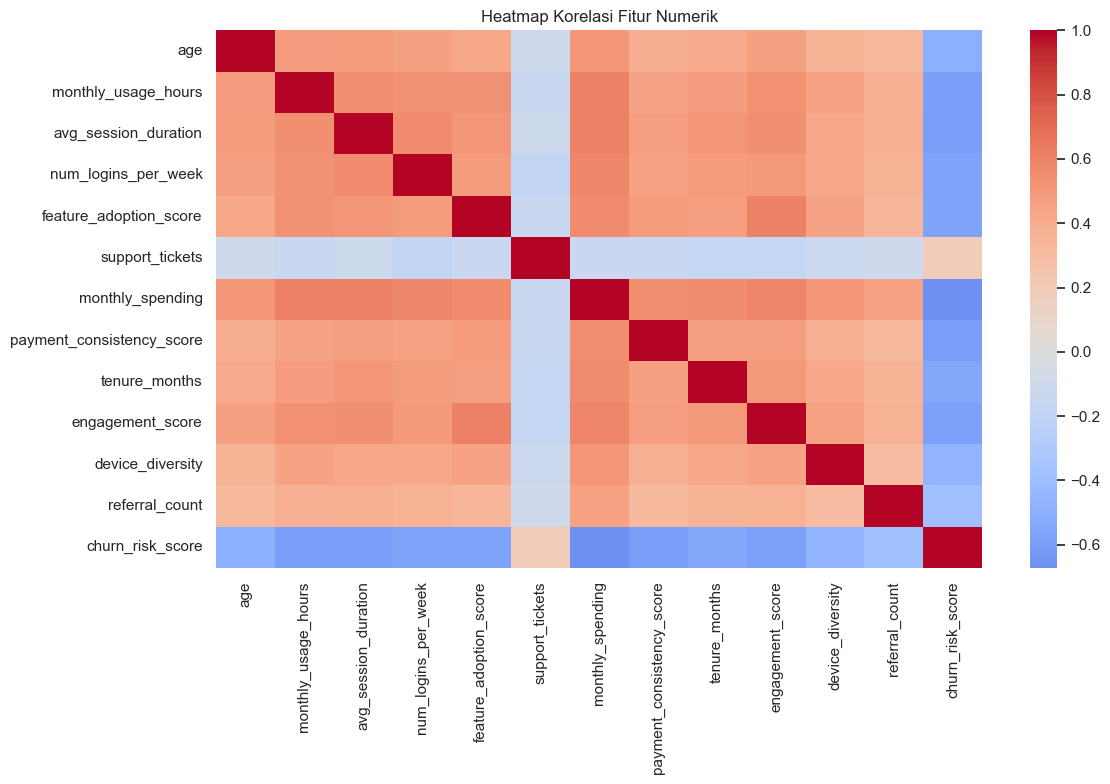

In [55]:
# Korelasi antar fitur numerik
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()


In [56]:
# Encode target ke numerik
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['segment_class_encoded'] = encoder.fit_transform(df['segment_class'])

# Hitung korelasi semua fitur dengan target
correlation_with_target = df.corr(numeric_only=True)['segment_class_encoded'].sort_values(ascending=False)

print(correlation_with_target)

segment_class_encoded        1.000000
engagement_score             0.300355
avg_session_duration         0.292571
monthly_spending             0.271990
feature_adoption_score       0.266431
monthly_usage_hours          0.260445
tenure_months                0.238524
payment_consistency_score    0.218487
num_logins_per_week          0.208301
device_diversity             0.204758
age                          0.199731
referral_count               0.100501
support_tickets             -0.060556
churn_risk_score            -0.277105
Name: segment_class_encoded, dtype: float64


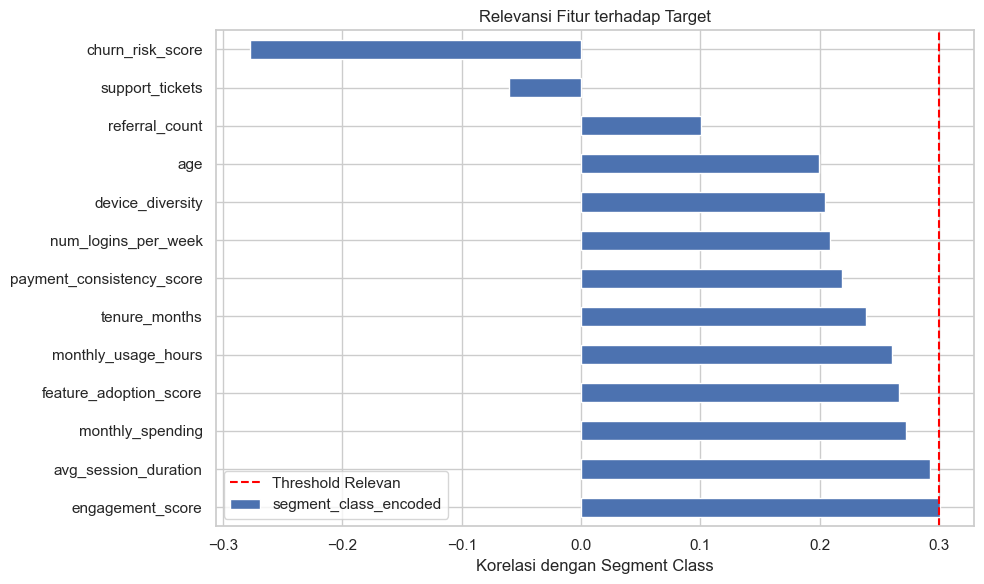

In [57]:
plt.figure(figsize=(10, 6))
correlation_with_target.drop('segment_class_encoded').plot(kind='barh')
plt.xlabel('Korelasi dengan Segment Class')
plt.title('Relevansi Fitur terhadap Target')
plt.axvline(x=0.3, color='red', linestyle='--', label='Threshold Relevan')
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
print("OUTLIER ANALYSIS (IQR Method)")

outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    
    if len(outliers) > 0:
        outlier_summary.append({
            'Fitur': col,
            'Jumlah_Outlier': len(outliers),
            'Persen_Outlier': round(outlier_pct, 2),
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2),
            'Min': round(df[col].min(), 2),
            'Max': round(df[col].max(), 2)
        })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Persen_Outlier', ascending=False)
print(outlier_df.to_string())

OUTLIER ANALYSIS (IQR Method)
                 Fitur  Jumlah_Outlier  Persen_Outlier  Lower_Bound  Upper_Bound   Min   Max
0                  age               3             0.3         8.36        55.66  18.0  58.9
3      support_tickets               3             0.3        -2.00         6.00   0.0   7.0
1  monthly_usage_hours               1             0.1        -7.65        82.35   3.0  87.5
2  num_logins_per_week               1             0.1        -2.55        17.05   1.0  19.4


## TUGAS MAHASISWA 2
Tuliskan temuan awal dari EDA:
1 Apakah distribusi kelas seimbang atau tidak,
2 Fitur mana yang tampak relevan,
3 Apakah ada missing value,
4 Potensi tantangan data untuk klasifikasi.


Pada tahap awal EDA yang telah dilakukan diatas dapat ditarik kesimpulan bahwa
1. Distribusi Kelas  
Berdasarkan analisis distribusi kelas sebagai berikut :  
- Enterprise: 257 / 1000 = 25.7%
- Premium: 253 / 1000 = 25.3%
- Growth: 245 / 1000 = 24.5%
- Basic: 245 / 1000 = 24.5%  

    Dapat disimpulkan bahwa distribusi data seimbang (balanced). Masing-masing kelas (Enterprise, Premium, Growth, Basic) memiliki jumlah sampel yang hampir sama (sekitar ~245 hingga ~257 data), dengan selisih hanya 12 row dari 1000 total. Hal ini sangat ideal karena tidak perlu teknik handling imbalanced data.  

2. Fitur Relevan   
Berdasarkan hasil korelasi yang pada target dengan menggunakan encoding untuk setiap fitur numerik diatas, yaitu dengan visualisasi barplot dan visualisasi heatmap diatas, terdapat beberapa fitur yang relevan pada target, seperti fitur seperti engagement_score (0.300355), avg_session_duration (0.292571), monthly_spending (0.271990), feature_adoption_score (0.266431), dan monthly_usage_hours (0.260445) kemungkinan besar sangat relevan untuk membedakan pelanggan. 

3. Missing Value  
Berdasarkan analisis missing value dengan value counts, terdapat beberapa missing value pada fitur feature_adoption_score (20), payment_consistency_score (15), last_campaign_response (15), dan preferred_plan (10). Missing value ini perlu ditangani agar tidak merusak kualitas model nantinya.

4. Potensi Tantangan  
- Dikarenakan sdanya missing value, maka diharuskan untuk melakukan missing value handling dengan proses imputasi.   
- Dataset memiliki 18 variabel (17 fitur + 1 target) dengan kombinasi fitur numerik dan kategori. Ini bisa menyebabkan curse of dimensionality.  
- Dataset ini memiliki tipe data campuran (numerik dan kategorikal), sehingga memerlukan tahapan encoding sebelum masuk ke pemodelan.  
- Terdapat beberapa outlier yang terdeteksi pada age (0.3%), support_tickets (0.3%), monthly_usage_hours (0.1%), dan num_logins_per_week (0.1%)
- Berdasarkan visualisasi heatmap korelasi numerik, terdapat redundansi informasi pada beberapa fitur. Misalnya, engagement_score memiliki korelasi yang nyata dengan feature_adoption_score dan churn_risk_score yang mungkin akan berefek pada model Naive Bayes yang mengandalkan independensi.

In [59]:
# =========================
# 4. Persiapan fitur dan target
# =========================
target_col = "segment_class"
drop_cols = ["customer_id", target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'monthly_usage_hours', 'avg_session_duration', 'num_logins_per_week', 'feature_adoption_score', 'support_tickets', 'monthly_spending', 'payment_consistency_score', 'tenure_months', 'engagement_score', 'device_diversity', 'referral_count', 'churn_risk_score', 'segment_class_encoded']
Categorical features: ['last_campaign_response', 'preferred_plan', 'region']


In [60]:
# Encode label target ke angka agar mudah divisualisasi dan dievaluasi
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
print("Class mapping:", dict(zip(class_names, range(len(class_names)))))


Class mapping: {'Basic': 0, 'Enterprise': 1, 'Growth': 2, 'Premium': 3}


In [61]:
# Train-test split dengan stratify agar proporsi kelas relatif terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (800, 17) Test size: (200, 17)


## TUGAS MAHASISWA 3
Jelaskan alasan penggunaan `stratify` pada proses train-test split.


Penggunaan parameter *stratify=y_encoded* pada *train_test_split()* digunakan untuk memastikan bahwa proporsi distribusi proporsi kelas target pada data train dan data test tetap konsisten dengan proporsi pada dataset aslinya. Penggunaan parameter ini berfungsi dalam klasifikasi multiclass agar model tidak bias terhadap satu kelas tertentu saat berlatih, dan agar evaluasi pada data test benar-benar representatif terhadap kondisi populasi data secara keseluruhan.   

In [62]:
# =========================
# 5. Preprocessing
# =========================
numeric_transformer_nb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

numeric_transformer_knn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_nb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_nb, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_knn, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_nb = preprocessor_nb.fit_transform(X_train)
X_test_nb = preprocessor_nb.transform(X_test)

X_train_knn = preprocessor_knn.fit_transform(X_train)
X_test_knn = preprocessor_knn.transform(X_test)

print("NB train shape:", X_train_nb.shape)
print("kNN train shape:", X_train_knn.shape)


NB train shape: (800, 29)
kNN train shape: (800, 29)


## TUGAS MAHASISWA 4
Mengapa standardisasi penting untuk kNN, tetapi tidak selalu menjadi langkah utama untuk Gaussian Naive Bayes?


Pada tahap preprocessing dilakukan splitting data terlebih dahulu sebelum dilakukan imputasi ataupun scaling agar menghindari data leakage, serta digunakan parameter stratify untuk menjaga distribusi data pada tahap splitting.   

Selanjutnya, dilakukan tahap preprocessing , dimana terdapat beberapa imputasi seperti pada 
- Variabel numeric untuk naive bayes dan knn dengan menggunakan median, alasannya adalah karena karena median jauh lebih kebal terhadap nilai outlier. Karena beberapa variabel fitur memiliki rentang yang besar, sehingga imputasi dengan mean akan lebih beresiko menggeser distribusi asli data.  
- Variabel categorical diimputasi dengan strategi most_frequent / modus, alasannya karena merupakan pendekatan paling logis untuk data categorical tanpa menciptakan kategori baru yang tidak relevan dengan data.  
- Penggunaan OneHotEncoding untuk beberapa fitur categorical digunakan untuk mencegah model berasumsi bahwa ada nilai matematis di antara kategori / hierarki. Serta penggunaan parameter handle_unknown="ignore" untuk memastikan pipeline tidak akan gagal jika nantinya pada data uji muncul kategori baru yang belum pernah dilihat saat pelatihan.  

Alasan standardisasi penting untuk knn adalah karena kNN adalah algoritma berbasis jarak spasial, dimana jika dilakukan tanpa standardisasi, fitur dengan rentang yang besar seperti ratusan akan mendominasi dan mengerdilkan fitur dengan rentang kecil seperti satuan. Oleh karena itu, standardisasi mengubah semua fitur numerik ke skala yang seragam dengan rata-rata=0 dan varians=1.  
Namun, pada Naive Bayes tidak urgent dilakukan standardisasi karena Naive Bayes adalah algoritma berbasis probabilitas bersyarat. Dimana algoritma ini menghitung nilai mean dan varians dari masing-masing fitur secara independen, sehingga perbedaan rentang skala antar fitur sama sekali tidak memengaruhi perhitungan probabilitas akhirnya. Sehingga tidak diperlukan untuk dilakukan standardisasi. 

In [63]:
# =========================
# 6. Model 1: Gaussian Naive Bayes
# =========================
nb_model = GaussianNB()
nb_model.fit(X_train_nb.toarray() if hasattr(X_train_nb, "toarray") else X_train_nb, y_train)

X_test_nb_dense = X_test_nb.toarray() if hasattr(X_test_nb, "toarray") else X_test_nb
y_pred_nb = nb_model.predict(X_test_nb_dense)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_f1_macro = f1_score(y_test, y_pred_nb, average="macro")
nb_precision_macro = precision_score(y_test, y_pred_nb, average="macro")
nb_recall_macro = recall_score(y_test, y_pred_nb, average="macro")

print("Naive Bayes Accuracy :", round(nb_accuracy, 4))
print("Naive Bayes F1 Macro :", round(nb_f1_macro, 4))
print("Naive Bayes Precision:", round(nb_precision_macro, 4))
print("Naive Bayes Recall   :", round(nb_recall_macro, 4))


Naive Bayes Accuracy : 1.0
Naive Bayes F1 Macro : 1.0
Naive Bayes Precision: 1.0
Naive Bayes Recall   : 1.0


In [64]:
print("Classification Report - Naive Bayes")
print(classification_report(y_test, y_pred_nb, target_names=class_names))


Classification Report - Naive Bayes
              precision    recall  f1-score   support

       Basic       1.00      1.00      1.00        49
  Enterprise       1.00      1.00      1.00        51
      Growth       1.00      1.00      1.00        49
     Premium       1.00      1.00      1.00        51

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



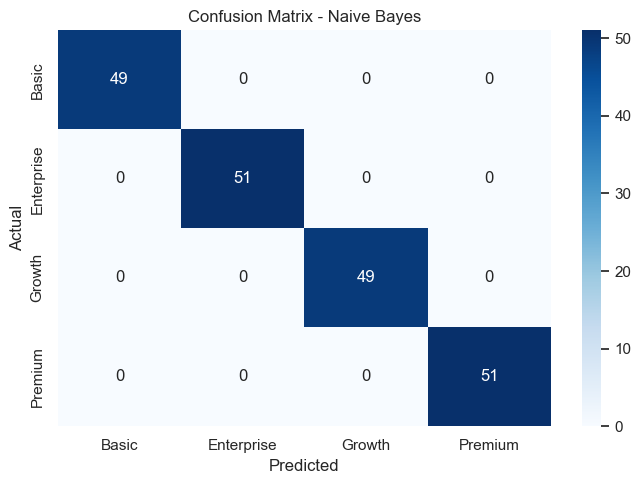

In [65]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(7,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## TUGAS MAHASISWA 5
Analisis hasil Naive Bayes:
1 Bagaimana performa umumnya,
2 Kelas mana yang paling baik diprediksi,
3 Kelas mana yang paling sering tertukar,
4 Apakah hasil ini sesuai dengan karakteristik data.


1. Performa umum  
Berdasarkan hasil performa model diatas didapatkan Naive Bayes Accuracy : 1.0, Naive Bayes F1 Macro : 1.0, Naive Bayes Precision: 1.0, Naive Bayes Recall   : 1.0, dimana model Naive Bayes berhasil memetakan batas keputusan tanpa ada satu pun kesalahan pada data uji. Seluruh kategori dipetakan tepat sesuai pada segmennya. 
2. Kelas terbaik  
Berdasarkan Classification Report, seluruh kelas baik itu Basic, Enterprise, Growth, dan Premium diprediksi dengan sempurna. Nilai Precision dan Recall untuk keempat segmen tersebut adalah 1.00. Dimana artinya, model tidak hanya mengenali semua pelanggan pada tiap segmen dengan tepat dengan 100% Recall, tetapi juga tidak pernah salah memasukkan pelanggan dari segmen lain ke dalam segmen tersebut dengan 100% Precision.  
3. Kelas tertukar  
Merujuk pada Confusion Matrix, tidak ada kelas yang tertukar sama sekali. Seluruh 200 data test set tepat di diagonal utama matriks dengan 49 Basic, 51 Enterprise, 49 Growth, 51 Premium. Titik-titik data antar segmen pelanggan tampaknya saling terisolasi dengan batas yang sangat tegas. 
4. Hasil dan Karakteristik  
Pencapaian skor 100% ini memberikan insight yang menarik tentang karakteristik datasetnya. Secara teori, Naive Bayes berasumsi bahwa setiap fitur itu independen satu sama lain. Walaupun pada saat EDA kita sempat menemukan adanya multikolinearitas, model tetap bisa mengklasifikasi dengan sempurna. Hal ini membuktikan bahwa batas antar-kelas di data ini sudah sangat tegas dan terpisah jauh. Sinyal pembeda dari tiap fiturnya sangat kuat, sehingga kelemahan bawaan Naive Bayes terkait asumsi independensi tadi sama sekali tidak mengganggu performa klasifikasinya pada kasus ini.

In [66]:
# =========================
# 7. Model 2: kNN + tuning hyperparameter
# =========================
results_knn = []

for k in [3, 5, 7, 9, 11]:
    for metric in ["euclidean", "manhattan"]:
        for weights in ["uniform", "distance"]:
            model = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights)
            model.fit(X_train_knn, y_train)
            y_pred = model.predict(X_test_knn)

            results_knn.append({
                "k": k,
                "metric": metric,
                "weights": weights,
                "accuracy": accuracy_score(y_test, y_pred),
                "f1_macro": f1_score(y_test, y_pred, average="macro"),
                "precision_macro": precision_score(y_test, y_pred, average="macro"),
                "recall_macro": recall_score(y_test, y_pred, average="macro")
            })

results_knn_df = pd.DataFrame(results_knn).sort_values(
    by=["f1_macro", "accuracy"], ascending=False
).reset_index(drop=True)

results_knn_df.head(10)


,k,metric,weights,accuracy,f1_macro,precision_macro,recall_macro
0,9,manhattan,uniform,0.955,0.955222,0.955822,0.955282
1,7,manhattan,distance,0.955,0.955036,0.955369,0.955282
2,9,manhattan,distance,0.950,0.950219,0.950720,0.950180
3,5,manhattan,uniform,0.950,0.950069,0.950813,0.950380
4,7,manhattan,uniform,0.950,0.950069,0.950813,0.950380
5,11,manhattan,uniform,0.950,0.950069,0.950813,0.950380
6,11,manhattan,distance,0.950,0.950069,0.950813,0.950380
7,5,manhattan,distance,0.945,0.945070,0.945511,0.945278
8,9,euclidean,uniform,0.940,0.939968,0.940409,0.940176
9,9,euclidean,distance,0.940,0.939968,0.940409,0.940176


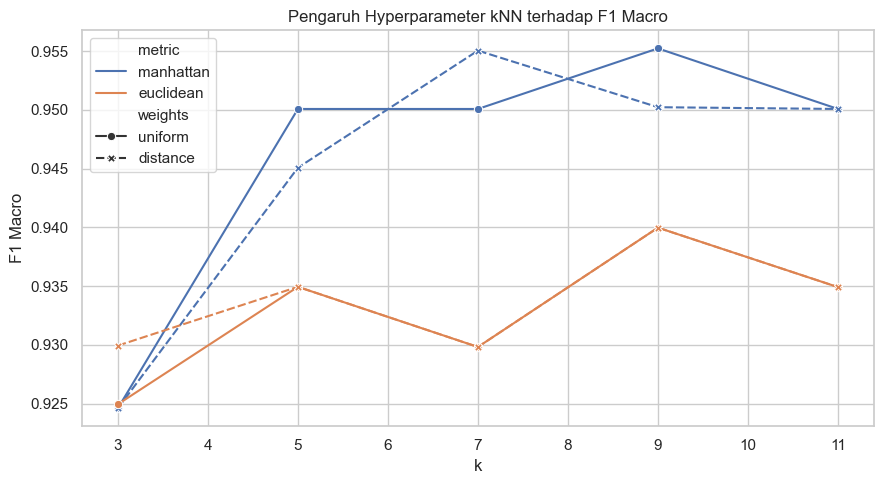

In [67]:
# Visualisasi tuning k berdasarkan F1 macro
plt.figure(figsize=(9,5))
sns.lineplot(data=results_knn_df, x="k", y="f1_macro", hue="metric", style="weights", markers=True)
plt.title("Pengaruh Hyperparameter kNN terhadap F1 Macro")
plt.ylabel("F1 Macro")
plt.tight_layout()
plt.show()


In [68]:
best_params = results_knn_df.iloc[0].to_dict()
best_params


{'k': 9,
 'metric': 'manhattan',
 'weights': 'uniform',
 'accuracy': 0.955,
 'f1_macro': 0.9552223570080712,
 'precision_macro': 0.9558217013220381,
 'recall_macro': 0.955282112845138}

In [69]:
best_knn = KNeighborsClassifier(
    n_neighbors=int(best_params["k"]),
    metric=best_params["metric"],
    weights=best_params["weights"]
)

best_knn.fit(X_train_knn, y_train)
y_pred_knn = best_knn.predict(X_test_knn)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1_macro = f1_score(y_test, y_pred_knn, average="macro")
knn_precision_macro = precision_score(y_test, y_pred_knn, average="macro")
knn_recall_macro = recall_score(y_test, y_pred_knn, average="macro")

print("Best kNN params:", best_params)
print("kNN Accuracy :", round(knn_accuracy, 4))
print("kNN F1 Macro :", round(knn_f1_macro, 4))
print("kNN Precision:", round(knn_precision_macro, 4))
print("kNN Recall   :", round(knn_recall_macro, 4))


Best kNN params: {'k': 9, 'metric': 'manhattan', 'weights': 'uniform', 'accuracy': 0.955, 'f1_macro': 0.9552223570080712, 'precision_macro': 0.9558217013220381, 'recall_macro': 0.955282112845138}
kNN Accuracy : 0.955
kNN F1 Macro : 0.9552
kNN Precision: 0.9558
kNN Recall   : 0.9553


In [70]:
print("Classification Report - Best kNN")
print(classification_report(y_test, y_pred_knn, target_names=class_names))


Classification Report - Best kNN
              precision    recall  f1-score   support

       Basic       0.94      0.96      0.95        49
  Enterprise       0.92      0.96      0.94        51
      Growth       0.98      0.98      0.98        49
     Premium       0.98      0.92      0.95        51

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.95      0.96       200



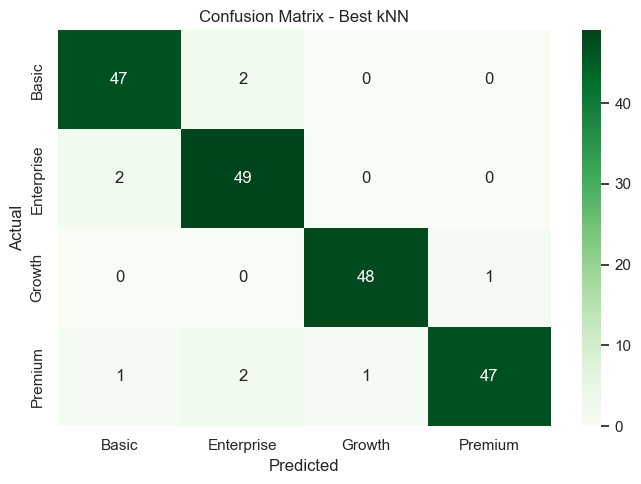

In [71]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(7,5))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Best kNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## TUGAS MAHASISWA 6
Analisis hasil tuning kNN:
1 Kombinasi hyperparameter terbaik,
2 Apakah perbedaan performa antar-konfigurasi besar atau kecil,
3 Apa kemungkinan alasan metric dan weights tertentu lebih baik,
4 Apa risiko jika memilih nilai k terlalu kecil atau terlalu besar.


1. Hyperparameter pada algoritma KNN dilakukan untuk menentukan nilai K yang paling tepat, agar tidak overfitting / underfitting. Pada model KNN ini dilakukan hyperparameter untuk matriks euclidean dan manhattan. Jika dilihat dari hasil tabel tuning dan visualisasi hyperparameter, terlihat bahwa kombinasi terbaik untuk mendapatkan nilai F1-Macro terbaik adalah dengan menggunakan matriks manhattan dengan nilai k = 9 dengan weights = uniform yang mendapatkan nilai F1-Macro 0.955. Selanjutnya kombinasi terburuk dengan F1-Macro 0.925 dimiliki oleh kombinasi matriks euclidean dengan nilai k = 3 dan weights = distance.  
2. Jika dilihat pada visualisasi, performa antar konfigurasi kombinasi metric, k, dan weights, tidak terlalu menunjukkan perbedaan yang signifikan, hanya berkisar antara ~93% hingga ~96%. Namun, dapat dilihat bahwa terdapat tren yang selalu konsisten, yaitu garis metrik manhattan (baik uniform maupun distance) hampir selalu berada di atas euclidean pada berbagai variasi k.  
3. Berdasarkan analisis pada nomor sebelumnya, didapatkan bahwa performa matriks manhattan baik uniform maupun distance akan selalu lebih baik daripada matriks euclidean, alasannya adalah karena dataset ini memiliki 17 fitur yang termasuk dalam dataset berdimensional tinggi. Dalam ruang berdimensinal tinggi, metrik Euclidean (L2 Norm) sering kali mengalami degradasi fungsi karena mengkuadratkan selisih jarak, sehingga sangat sensitif terhadap perbedaan besar pada satu atau dua fitur saja yang artinya matriks ini terkena dampak curse of dimensionality. Sebaliknya, jarak Manhattan (L1 Norm) yang menghitung selisih absolut secara "grid" yang terbukti lebih tangguh / robust dalam menangani banyak fitur sekaligus. Selanjutnya, jika dilihat dari hasil tabel tuning, dilihat bahwa weights uniform lebih menghasilkan performa yang baik daripada weights distance yang mengindikasikan bahwa kepadatan data di sekitar batas antar kelas cukup merata.
4. Jika dilihat dari visualisasi diatas, 
- Jika k terlalu kecil, contohnya seperti k=3: Terlihat di grafik bahwa performa k=3 adalah yang terendah. Nilai k yang kecil membuat model terlalu kompleks dan sangat reaktif terhadap noise atau outlier di area lokal (Overfitting).
- Jika k terlalu besar contohnya seperti k > 11 : Tren grafik mulai menunjukkan sedikit stagnasi atau penurunan setelah k=9. Jika diteruskan ke k yang lebih besar, misal k=20, model akan menjadi terlalu kaku (Underfitting). Prediksi akan didominasi oleh kelas mayoritas secara global, dan model akan gagal menangkap profil spesifik dari segmen pelanggan yang unik.  
    Oleh karena itu, k=9 adalah sweet spot yang berhasil menyeimbangkan varians yang tidak terlalu sensitif terhadap noise dan bias sehingga tetap mampu membedakan batas kelas dengan halus. 

In [72]:
# =========================
# 8. Perbandingan model
# =========================
comparison_df = pd.DataFrame([
    {
        "Model": "Gaussian Naive Bayes",
        "Accuracy": nb_accuracy,
        "Precision_macro": nb_precision_macro,
        "Recall_macro": nb_recall_macro,
        "F1_macro": nb_f1_macro
    },
    {
        "Model": "Best kNN",
        "Accuracy": knn_accuracy,
        "Precision_macro": knn_precision_macro,
        "Recall_macro": knn_recall_macro,
        "F1_macro": knn_f1_macro
    }
])

comparison_df.sort_values(by="F1_macro", ascending=False)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Gaussian Naive Bayes,1.000,1.000000,1.000000,1.000000
1,Best kNN,0.955,0.955822,0.955282,0.955222


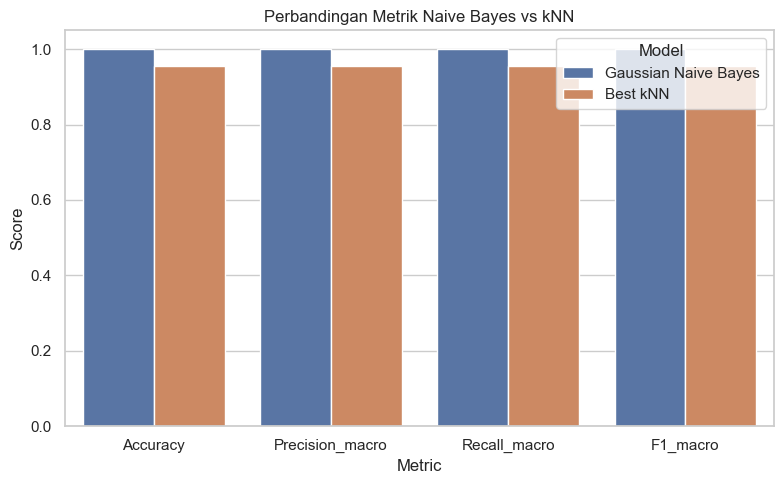

In [73]:
plt.figure(figsize=(8,5))
comparison_long = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=comparison_long, x="Metric", y="Score", hue="Model", palette="deep")
plt.ylim(0, 1.05)
plt.title("Perbandingan Metrik Naive Bayes vs kNN")
plt.tight_layout()
plt.show()


## TUGAS MAHASISWA 7
Bandingkan Naive Bayes dan kNN:
1 Model mana yang lebih unggul pada dataset ini,
2 Apakah model terbaik juga yang paling stabil,
3 Model mana yang lebih sederhana untuk diimplementasikan,
4 Dalam konteks bisnis, model mana yang Anda rekomendasikan dan mengapa.


Berdasarkan analisis kedua model yang telah dilakukan, didapatkan
1. Seperti yang terlihat di visualisasi diatas, didapatkan naive bayes memiliki nilai akurasi 1.00 , presisi 1.00, recall 1.00 dan f1_macro 1.00, sedangkan knn yang telah melalui hyperparameter memiliki nilai akurasi 0.95 , presisi 0.955, recall 0.95 dan f1_macro 0.95. Sehingga dapat disimpulkan bahwa untuk dataset ini model naive bayes lebih unggul dengan mencetak skor sempurna. Perbedaan performa ini menegaskan bahwa untuk dataset spesifik ini, pendekatan probabilitas bersyarat memiliki performa lebih baik dibandingkan pendekatan jarak spasial. 
2. Ya, karena model naive bayes tanpa perlu dilakukannya tuning parameter apa pun, model ini mampu memisahkan batas kelas secara sempurna dengan 0 error antar kelas. Namun sebaliknya, performa kNN sangat fluktuatif dan sensitif terhadap perubahan hyperparameter sehingga sangat rentan terhadap overfitting/underfitting. Jika kita melihat error antar kelas untuk setiap model terlihat bahwa kelas Premium adalah yang paling tidak stabil dengan nilai Recall terendah yaitu 0.92, dimana ada sekitar 8% pelanggan Premium yang gagal dideteksi oleh knn. Sebaliknya, kelas Growth pada knn adalah yang paling mudah diprediksi karena F1-score 0.98. Namun, naive bayes menghilangkan semua instabilitas ini dengan mendeteksi 100% pelanggan di setiap kelas dengan presisi penuh.  
3. Model yang paling sederhana untuk diimplementasikan adalah naive bayes, karena beberapa hal berikut : 
- naive bayes tidak menghitung jarak, sehingga kebal terhadap perbedaan skala antar-fitur, sehingga tidak diperlukan scaling. 
- tidak perlu dilakukan tuning hyperparameter, sehingga akan mengurangi waktu training.
4. Dalam konteks bisnis, saya merekomendasikan naive bayes karena jika dilihat pada model knn yang memiliki error tertinggi 8% pada pelanggan premium akan berakibat fatal, contohnya jika pelanggan Premium atau Enterprise salah diklasifikasikan sebagai Basic dan menerima penawaran/layanan yang di bawah standar, perusahaan berisiko tinggi mengalami churn dari pelanggan bernilai tinggi. Dengan model naive bayes, maka seluruh pelanggan akan dikategorisasi sesuai dengan segmen yang tepat dan akan mendapatkan pelayanan sesuai segmen. Dan juga, secara arsitektur sistem informasi, naive bayes jauh lebih ringan saat melakukan inferensi data pelanggan secara real-time. Model ini hanya menyimpan tabel rata-rata dan varians. Sehingga tidak akan membebani server apabila terdapat data baru yang diinput.

In [74]:
# =========================
# 9. Visualisasi aktual vs prediksi
# Gunakan PCA 2D agar data berdimensi tinggi dapat divisualisasikan
# =========================
X_full_knn = preprocessor_knn.fit_transform(X, y_encoded)
X_full_dense = X_full_knn.toarray() if hasattr(X_full_knn, "toarray") else X_full_knn

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full_dense)

# Prediksi pada seluruh data untuk tujuan visualisasi
nb_model_full = GaussianNB()
nb_model_full.fit(
    X_full_dense,
    y_encoded
)
y_full_pred_nb = nb_model_full.predict(X_full_dense)

knn_model_full = KNeighborsClassifier(
    n_neighbors=int(best_params["k"]),
    metric=best_params["metric"],
    weights=best_params["weights"]
)
knn_model_full.fit(X_full_knn, y_encoded)
y_full_pred_knn = knn_model_full.predict(X_full_knn)

viz_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "actual": label_encoder.inverse_transform(y_encoded),
    "pred_nb": label_encoder.inverse_transform(y_full_pred_nb),
    "pred_knn": label_encoder.inverse_transform(y_full_pred_knn)
})

viz_df.head()


,PC1,PC2,actual,pred_nb,pred_knn
0,1.558947,1.930229,Premium,Premium,Premium
1,0.831099,1.137744,Premium,Premium,Premium
2,0.051755,0.327252,Premium,Premium,Premium
3,0.585239,0.312887,Premium,Premium,Premium
4,-1.321565,0.513204,Growth,Growth,Growth


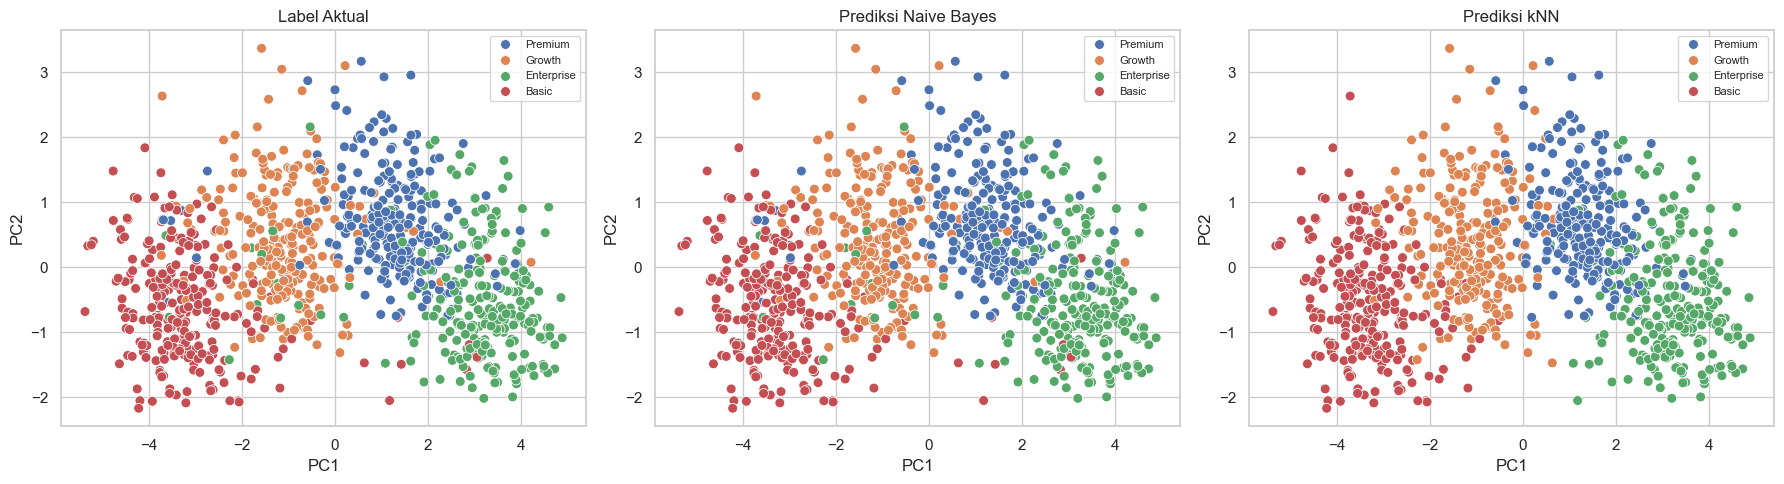

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="actual", ax=axes[0], s=50)
axes[0].set_title("Label Aktual")

sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="pred_nb", ax=axes[1], s=50)
axes[1].set_title("Prediksi Naive Bayes")

sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="pred_knn", ax=axes[2], s=50)
axes[2].set_title("Prediksi kNN")

for ax in axes:
    ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


In [76]:
# Sampel aktual vs prediksi untuk analisis error
sample_compare = pd.DataFrame({
    "actual": label_encoder.inverse_transform(y_test),
    "pred_nb": label_encoder.inverse_transform(y_pred_nb),
    "pred_knn": label_encoder.inverse_transform(y_pred_knn)
}).sample(20, random_state=42)

sample_compare


,actual,pred_nb,pred_knn
95,Premium,Premium,Premium
15,Enterprise,Enterprise,Enterprise
30,Premium,Premium,Premium
158,Growth,Growth,Growth
128,Growth,Growth,Growth
115,Premium,Premium,Premium
69,Basic,Basic,Basic
170,Enterprise,Enterprise,Enterprise
174,Basic,Basic,Basic
45,Basic,Basic,Basic


## TUGAS MAHASISWA 8
Amati visualisasi aktual vs prediksi:
1 Apakah pemisahan kelas terlihat jelas,
2 Model mana yang tampak lebih mendekati distribusi aktual,
3 Kesalahan klasifikasi apa yang paling menonjol dari visualisasi maupun confusion matrix.


Berdasarkan hasil visualisasi diatas
1. Apabila hanya dilihat pada visualisasi plot PCA 2D, terlihat 4 kelompok besar, namun batas antar kelas tidak bisa terlihat dengan jelas dan masih overlapping terutama di area pusat sebaran data. Hal ini diakibatkan karena adanya penumpukan visual karena banyak informasi varians yang hilang saat direduksi menjadi 2 dimensi. Namun jika dilihat pada 17 dimensi, maka akan terlihat jelas batas antar kelasnya karena naive bayes memetakan tepat 100% segmen pelanggan tersebut. 
2. Berdasarkan visualisasi diatas, sebaran warna pada plot prediksi naive bayes mereplikasi secara sempurna sebaran segmen seperti data aktual. Tidak ada satu pun titik data yang berubah warna. Hal ini sejalan dengan metrik evaluasi sebelumnya di mana Naive Bayes tidak menghasilkan error sama sekali. Sebaliknya, plot prediksi knn juga terlihat sangat merepresentasikan distribusi aktual secara makro. Namun, jika diteliti lebih lanjut, terdapat beberapa titik yang berbeda dengan warna yang ada di data aktual.
3. Keasalahan klasifikasi yang terlihat pada knn, yaitu pada confusion matrix sebelumnya mengungkapkan bahwa kelas Premium adalah yang paling sering misclassified, serta jika kita merujuk pada plot PCA, kesalahan knn ini sangat logis terjadi di area sentral/pusat sebaran di mana semua warna saling bertabrakan padat. Karena knn salah menarik kesimpulan dari mayoritas tetangganya.

## TUGAS MAHASISWA 9
Tuliskan kesimpulan akhir Anda dalam 2–4 paragraf dengan mencakup:
1. Model terbaik dan alasan berbasis bukti,
2. Pengaruh hyperparameter pada kNN,
3. Keterbatasan analisis,
4. Saran pengembangan berikutnya.


Berdasarkan keseluruhan proses pemodelan serta analisis yang telah dilakukan, naive bayes menjadi model terbaik untuk dataset segmentasi pelanggan ini, model ini memiliki F1-makro score 1.00 (100%) pada seluruh metrik evaluasi. Performa yang dimiliki model ini melampaui model knn yang mencapai  F1-makro score maksimal 95.5% bahkan setelah dilakukannya tuning hyperparameter. Hal ini memberikan bukti bahwa dataset ini memiliki batas antar-kelas yang sangat tegas di ruang berdimensi tinggi. Kuatnya sinyal pembeda dari setiap fitur membuat kalkulasi probabilitas bersyarat pada naive bayes bekerja sangat optimal, bahkan mengabaikan asumsi independensi fiturnya sempat terlanggar akibat adanya multikolinearitas yang ditemukan pada tahap Exploratory Data Analysis (EDA).   

Meskipun tidak menjadi model terbaik pada dataset ini. eksperimen pada knn memberikan wawasan mengenai pentingnya hyperparameter tuning dalam mengatasi kelemahan arsitektur spasial. Hasil optimasi membuktikan bahwa knn sangat rentan terhadap Curse of Dimensionality yang ditunjukkan oleh buruknya performa metrik Euclidean. Performa model baru berhasil dioptimalkan setelah menerapkan metrik Manhattan (L1 Norm) yang lebih tangguh, dipadukan dengan nilai k=9 dan bobot suara yang setara (uniform). Konfigurasi ini terbukti menjadi yang paling tepat untuk menyeimbangkan Bias-Variance Tradeoff, menghindarkan model dari overfitting yang sempat terjadi pada k=3, sekaligus mengabaikan noise di area perbatasan kelas.   

Namun demikian, analisis ini memiliki sejumlah keterbatasan. Pencapaian skor sempurna 100% pada Naive Bayes mengindikasikan bahwa distribusi dataset saat ini sangat ideal dan minim noise, suatu kondisi yang sangat jarang ditemui pada dinamika perilaku konsumen di dunia nyata. Hal ini memunculkan pertanyaan terkait ketahanan model jika nantinya dihadapkan pada data ril produksi yang jauh lebih kompleks dan bising. Selain itu, penggunaan PCA 2D terbukti kurang efektif dalam memvisualisasikan batas pemisahan kelas secara akurat pada ruang data berdimensi 17 ini.  

Sebagai saran pengembangan berikutnya, untuk kebutuhan bisnis strategis, sangat direkomendasikan untuk menerapkan algoritma berbasis pohon seperti Tree-based models seperti Random Forest atau XGBoost untuk mengekstraksi Feature Importance, sehingga perusahaan tidak hanya bisa memprediksi segmen, tetapi juga mengetahui secara pasti fitur mana yang paling memengaruhi perpindahan pelanggan dari segmen Basic ke Premium atau Enterprise. 

## Deklarasi Penggunaan AI

Saya menyatakan bahwa dalam pengerjaan tugas ini:

1. Saya memahami bahwa penggunaan alat berbasis Artificial Intelligence (AI) seperti ChatGPT, Copilot, atau tools serupa **diperbolehkan secara terbatas** hanya sebagai alat bantu pembelajaran.

2. Jika saya menggunakan AI, maka penggunaan tersebut hanya sebatas untuk:
   - memahami konsep,
   - membantu debugging kode,
   - memberikan referensi struktur atau sintaks.

3. Saya **tidak menggunakan AI untuk secara langsung menghasilkan seluruh solusi tanpa pemahaman**, termasuk:
   - menyalin penuh kode tanpa modifikasi,
   - menyalin hasil analisis tanpa interpretasi pribadi.

4. Seluruh kode, analisis, dan kesimpulan dalam notebook ini:
   - telah saya pahami,
   - dapat saya jelaskan secara mandiri.

5. Saya bersedia menjelaskan setiap bagian dari pekerjaan ini apabila diminta oleh dosen.

6. Jika terdapat bagian yang dibantu oleh AI, saya mencantumkannya secara transparan di bawah ini:

### Bagian yang menggunakan AI (jika ada):
- Pemahaman konsep teoretis terkait multikolinearitas dan asumsi dasar algoritma (EDA)
- Pemahaman konsep hyperparameter (Tuning)
- Penjelasan konsep dasar Bias-Variance Tradeoff dan Curse of Dimensionality dalam konteks Machine Learning.
- Pemahaman konsep mengenai visualisasi PCA (PCA)
- Tools

### Penjelasan penggunaan:
Saya menggunakan AI (Google Gemini) sebagai referensi pembelajaran dan mitra diskusi untuk menguasai landasan teoretis dari setiap tahapan yang saya kerjakan. Pada tahap Exploratory Data Analysis (EDA), saya meminta penjelasan konseptual mengenai gejala multikolinearitas dan bagaimana hal tersebut berinteraksi dengan asumsi dasar algoritma. Memasuki tahap Hyperparameter Tuning, AI membantu saya memahami filosofi di balik pengaturan parameter itu sendiri, serta memberikan pemahaman dasar mengenai fenomena Bias-Variance Tradeoff dan Curse of Dimensionality dalam konteks Machine Learning. Terakhir, saya menggunakan AI untuk mempelajari cara kerja dan batasan teoretis dari reduksi dimensi pada visualisasi PCA. Perlu ditekankan bahwa AI hanya memberikan penjelasan teori. Seluruh analisis spesifik terhadap dataset, pembacaan metrik evaluasi, interpretasi visualisasi, hingga penarikan kesimpulan akhir di dalam notebook ini murni merupakan hasil pemikiran, telaah, dan usaha mandiri saya.

---

Saya menyatakan bahwa pekerjaan ini merupakan hasil pemahaman dan usaha saya sendiri.

**Nama:**  Aliya Harta Ary Utama
**NIM:**  18223081
**Tanggal:** Minggu 26 April 2026